# This Jupyter Notebook searches for runaways coming from R136 based on the stars defined in R136_runaway_candidates.ipynb

# Expected runtime: 7-8 hours for entire dataset of 69 runaways
# Expected runtime: 15-30 minutes for smaller dataset of three runaways as proof-of-concept

In [4]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import os
import matplotlib
import pymc as pm
import corner
import arviz as az
import pytensor as pt

%matplotlib inline

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


small check:

In [5]:
import sys
from pathlib import Path

print(sys.executable)

for f in [
    "output_files/runaways_raw_zp_1deg.csv",
    "output_files/runaways_cands.csv",
    "output_files/runaways_mcmc.csv",
]:
    p = Path(f)
    print(f, p.exists(), f"{p.stat().st_size/1e6:.2f} MB" if p.exists() else "")

C:\Users\bukow\anaconda3\envs\R136_waves\python.exe
output_files/runaways_raw_zp_1deg.csv True 138.63 MB
output_files/runaways_cands.csv True 36.47 MB
output_files/runaways_mcmc.csv True 0.13 MB


# File directory

In [6]:
cwd = os.getcwd()
output_dir = 'output_files/'
input_files_dir = 'input_files/'

# Load in Runaway Candidates

In [7]:
runaways_cands = ps.read_csv(output_dir + 'runaways_cands.csv')

C:\Users\bukow\AppData\Local\Temp\ipykernel_64868\1143540194.py:1: DtypeWarning: Columns (158) have mixed types. Specify dtype option on import or set low_memory=False.
  runaways_cands = ps.read_csv(output_dir + 'runaways_cands.csv')


# Runaway Search Parameters

In [8]:
# cut-off values for runaways

# how long ago we search back for
runaway_time_max = -3.5e6 # yr

# preliminary runaway transverse velocity accuracy requirement -> v_t / v_t_error > v_t_sigma
v_t_sigma = 2.5

# preliminary runaway transverse velocity threshold
v_out_min_runaway = 25.0 # km/s

# the proper motion ellipse should overlap with R136 considering this sigma
pm_passage_sigma = 2

# seach for runaways outside this radius

# radius of R136
r_cluster = 0.005 # deg


# Galactic coordinates

In [9]:
# this function transforms icrs j2000 equatorial astrometry to j2000 galactic astrometry following the gaia edr3 description
def icrs_to_gal(ra, ra_error, dec, dec_error, parallax, parallax_error, pmra, pmra_error, pmdec, pmdec_error,
                ra_dec_corr, ra_parallax_corr, ra_pmra_corr, ra_pmdec_corr, dec_parallax_corr, dec_pmra_corr,
                dec_pmdec_corr, parallax_pmra_corr, parallax_pmdec_corr, pmra_pmdec_corr):
    
    A_prime_G = np.array([[-0.0548755604162154, -0.8734370902348850, -0.4838350155487132], [0.4941094278755837, -0.4448296299600112, 0.7469822444972189], [-0.8676661490190047, -0.1980763734312015, 0.4559837761750669]])
    
    # icrs position vector
    r_icrs = np.array([np.cos(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(ra))*np.cos(np.radians(dec)), np.sin(np.radians(dec))])
    
    # galactic position vector
    r_gal_0 = np.sum(A_prime_G[0,:]*r_icrs)
    r_gal_1 = np.sum(A_prime_G[1,:]*r_icrs)
    r_gal_2 = np.sum(A_prime_G[2,:]*r_icrs)
                      
    # calculate galactic l and b
    l = np.degrees(np.arctan2(r_gal_1, r_gal_0))
    b = np.degrees(np.arctan2(r_gal_2, np.sqrt(r_gal_0**2 + r_gal_1**2)))
    
    p_icrs = np.array([-np.sin(np.radians(ra)), np.cos(np.radians(ra)), 0.])
    q_icrs = np.array([-np.cos(np.radians(ra))*np.sin(np.radians(dec)), -np.sin(np.radians(ra))*np.sin(np.radians(dec)), np.cos(np.radians(dec))])
    
    p_gal = np.array([-np.sin(np.radians(l)), np.cos(np.radians(l)), 0.])
    q_gal = np.array([-np.cos(np.radians(l))*np.sin(np.radians(b)), -np.sin(np.radians(l))*np.sin(np.radians(b)), np.cos(np.radians(b))])
    
    pm_icrs = p_icrs*pmra + q_icrs*pmdec
    
    pm_gal_0 = np.sum(A_prime_G[0,:]*pm_icrs)
    pm_gal_1 = np.sum(A_prime_G[1,:]*pm_icrs)
    pm_gal_2 = np.sum(A_prime_G[2,:]*pm_icrs)
    
    # calculate galactic pml and pmb
    pml = p_gal[0]*pm_gal_0 + p_gal[1]*pm_gal_1 + p_gal[2]*pm_gal_2
    pmb = q_gal[0]*pm_gal_0 + q_gal[1]*pm_gal_1 + q_gal[2]*pm_gal_2
    
    matr_icrs = np.array([[p_icrs[0], q_icrs[0]], [p_icrs[1], q_icrs[1]], [p_icrs[2], q_icrs[2]]])
    matr_gal_prime = np.array([[p_gal[0], q_gal[0]], [p_gal[1], q_gal[1]], [p_gal[2], q_gal[2]]]).T
    
    # obtain G, describing ICRS to galactic rotation
    G = np.matmul(matr_gal_prime, np.matmul(A_prime_G, matr_icrs))
    
    # obtain J, the Jacobian of the transformation
    J = np.array([[G[0,0], G[0,1], 0, 0, 0],
                 [G[1,0], G[1,1], 0, 0, 0],
                 [0, 0, 1, 0, 0], 
                 [0, 0, 0, G[0,0], G[0,1]],
                 [0, 0, 0, G[1,0], G[1,1]]])
    
    # ICRS covariance matrix
    C = np.array([[ra_error**2, ra_error*dec_error*ra_dec_corr, ra_error*parallax_error*ra_parallax_corr, ra_error*pmra_error*ra_pmra_corr, ra_error*pmdec_error*ra_pmdec_corr],
                 [dec_error*ra_error*ra_dec_corr, dec_error**2, dec_error*parallax_error*dec_parallax_corr, dec_error*pmra_error*dec_pmra_corr, dec_error*pmdec_error*dec_pmdec_corr],
                 [parallax_error*ra_error*ra_parallax_corr, parallax_error*dec_error*dec_parallax_corr, parallax_error**2, parallax_error*pmra_error*parallax_pmra_corr, parallax_error*pmdec_error*parallax_pmdec_corr],
                 [pmra_error*ra_error*ra_pmra_corr, pmra_error*dec_error*dec_pmra_corr, pmra_error*parallax_error*parallax_pmra_corr, pmra_error**2, pmra_error*pmdec_error*pmra_pmdec_corr],
                 [pmdec_error*ra_error*ra_pmdec_corr, pmdec_error*dec_error*dec_pmdec_corr, pmdec_error*parallax_error*parallax_pmdec_corr, pmdec_error*pmra_error*pmra_pmdec_corr, pmdec_error**2]])
    
    
    C_gal = np.matmul(J, np.matmul(C, J.T))
    
    l_error = np.sqrt(C_gal[0,0])
    b_error = np.sqrt(C_gal[1,1])
    pml_error = np.sqrt(C_gal[3,3])
    pmb_error = np.sqrt(C_gal[4,4])
    l_b_corr = C_gal[0,1]/(l_error*b_error)
    l_parallax_corr = C_gal[0,2]/(l_error*parallax_error)
    l_pml_corr = C_gal[0,3]/(l_error*pml_error)
    l_pmb_corr = C_gal[0,4]/(l_error*pmb_error)
    b_parallax_corr = C_gal[1,2]/(b_error*parallax_error)
    b_pml_corr = C_gal[1,3]/(b_error*pml_error)
    b_pmb_corr = C_gal[1,3]/(b_error*pmb_error)
    parallax_pml_corr = C_gal[2,3]/(parallax_error*pml_error)
    parallax_pmb_corr = C_gal[2,4]/(parallax_error*pmb_error)
    pml_pmb_corr = C_gal[3,4]/(pml_error*pmb_error)
    
    return l, l_error, b, b_error, pml, pml_error, pmb, pmb_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr

# this function transforms the galactic proper motion to equatorial proper motion given the ra and dec
def gal_icrs_pm_finder(ra, dec, pml, pmb):
    best_pmlb = 1e10
    pmra_best = 1e10
    pmdec_best = 1e10
    pmtot = np.sqrt(pml**2 + pmb**2)
    
    for pmra_cur in np.arange(0.0001, pmtot, 0.0001):
        pmdec_cur = np.sqrt(pmtot**2 - pmra_cur**2)
        l_cur, l_error_cur, b_cur, b_error_cur, pml_cur, pml_error_cur, pmb_cur, pmb_error_cur, l_b_corr_cur, l_parallax_corr_cur, l_pml_corr_cur, l_pmb_corr_cur, b_parallax_corr_cur, b_pml_corr_cur, b_pmb_corr_cur, parallax_pml_corr_cur, parallax_pmb_corr_cur, pml_pmb_corr_cur = icrs_to_gal(ra, 0.01, dec, 0.01, 0.01, 0.01, pmra_cur, 0.01, pmdec_cur, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01)
        pml_diff = np.abs(pml - pml_cur)
        pmb_diff = np.abs(pmb - pmb_cur)
        if pml_diff + pmb_diff < best_pmlb:
            pmra_best = pmra_cur
            pmdec_best = pmdec_cur
            best_pmlb = pml_diff + pmb_diff
    
    return pmra_best, pmdec_best
        

# R136 Galactic Astrometry

In [10]:
ra_cluster = 84.6767920 # position of R136a1
dec_cluster = -69.1006110 # position of R136a1

# median ra and dec proper motion of the runaway candidates 5 arcminutes from R136 with good astrometry
median_pmra_cands = np.median(runaways_cands.pmra[np.sqrt(((runaways_cands.ra - ra_cluster)/(np.cos(np.radians(dec_cluster))))**2 + (runaways_cands.dec - dec_cluster)**2) < (5/60)])
median_pmdec_cands = np.median(runaways_cands.pmdec[np.sqrt(((runaways_cands.ra - ra_cluster)/(np.cos(np.radians(dec_cluster))))**2 + (runaways_cands.dec - dec_cluster)**2) < (5/60)])

# transform to galactic coordinates. 0.01 values don't matter here, they are just filler
l_cluster, l_cluster_error, b_cluster, b_cluster_error, pml_cluster, pml_cluster_error, pmb_cluster, pmb_cluster_error, l_b_corr, l_parallax_corr, l_pml_corr, l_pmb_corr, b_parallax_corr, b_pml_corr, b_pmb_corr, parallax_pml_corr, parallax_pmb_corr, pml_pmb_corr= icrs_to_gal(84.6766610, 0.01, -69.1008054, 0.01, 0.02, 0.001, median_pmra_cands, 0.01, median_pmdec_cands, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01)
l_cluster = l_cluster + 360
print(l_cluster, b_cluster, pml_cluster, pmb_cluster)


279.4650106407674 -31.67189829385359 -0.8252867833400861 1.5893120739753555


# Find runaways with R136 proper motion as free parameters

In [11]:
# this function traces each runaway in a dataframe back with respect to R136
# it checks whether it passes within a certain treshold (2 sigma) here
# if the trace-back time, kinematic age, is smaller than 3.5 Myr it passes
def runaway_finder(runaways_cur, runaway_time_max, r_cluster, l_centre, b_centre, pml_cluster, pmb_cluster, pm_passage_sigma):
    time_array = np.arange(runaway_time_max, 0.01e6, 0.01e6)
    runaways = runaways_cur.copy()
    runaways_alt = runaways_cur.copy()
    runaway_t_max = 3.0
    
    for index, row in runaways.iterrows():
        l_time = row.l + time_array*row.pml/(3600000*np.cos(np.radians(row.b))) - (l_centre + time_array*pml_cluster/(3600000*np.cos(np.radians(b_centre))))
        b_time = row.b + time_array*row.pmb/3600000 - (b_centre + time_array*pmb_cluster/3600000)
        
        r_sep_min = np.amin(np.sqrt(l_time**2 + b_time**2))
        time_min = time_array[np.argmin(np.sqrt(l_time**2 + b_time**2))]
        l_time_min_err = np.abs(time_min*row.pml_error/(3.6e6*np.cos(np.radians(row.b))))
        b_time_min_err = np.abs(time_min*row.pmb_error/(3.6e6))
        max_err = np.amax([l_time_min_err, b_time_min_err])
        mean_err = np.mean([l_time_min_err, b_time_min_err])
        
        # runaway error-region should come within X sigma of the cluster centre
        # is also a runaway if the minimum separation is smaller than a few times the cluster radius for the runaways with very low tkin
        if (r_sep_min < pm_passage_sigma*max_err) or (r_sep_min < r_cluster):
            runaways_alt.loc[runaways_alt.source_id == row.source_id, 'r_impact'] = np.around(np.amin(np.sqrt(l_time**2 + b_time**2)), 3)
            runaways_alt.loc[runaways_alt.source_id == row.source_id, 't_kin'] = np.around(time_array[np.argmin(np.sqrt(l_time**2 + b_time**2))]/(-1e6), 2)
            
            # remove sources that have a kinematic age that is too large
            if runaways_alt[runaways_alt.source_id == row.source_id].t_kin.to_numpy()[0] > runaway_t_max:
                runaways_alt = runaways_alt[~(runaways_alt.source_id.to_numpy() == row.source_id)]
        else:
            runaways_alt = runaways_alt[~(runaways_alt.source_id.to_numpy() == row.source_id)]
        
    print(len(runaways), len(runaways_alt))
    return runaways_alt

# this function finds the sum of the impact parameter of the runaways normalised to the number of runaways
def r_impact_finder(runaways, l_centre, b_centre, pml_cluster, pmb_cluster):
    time_array = np.arange(runaway_time_max, 0.01e6, 0.01e6)
    r_impact = 0
    
    for index, row in runaways.iterrows():
        l_time = row.l + time_array*row.pml/(3600000*np.cos(np.radians(row.b))) - (l_centre + time_array*pml_cluster/(3600000*np.cos(np.radians(b_centre))))
        b_time = row.b + time_array*row.pmb/3600000 - (b_centre + time_array*pmb_cluster/3600000)
        
        r_impact_min = np.amin(np.sqrt(l_time**2 + b_time**2))
        time_min = time_array[np.argmin(np.sqrt(l_time**2 + b_time**2))]
        l_time_min_err = np.abs(time_min*row.pml_error/(3.6e6*np.cos(np.radians(row.b))))
        b_time_min_err = np.abs(time_min*row.pmb_error/(3.6e6))
        lb_min_err = np.mean([l_time_min_err, b_time_min_err])
        
        r_impact_sigma = r_impact_min / lb_min_err
        r_impact += r_impact_sigma
    r_impact = r_impact / len(runaways)
    return r_impact

# this function keeps all runaways which satisfy the necessary criteria
# velocity should be significant
# velocity vector should be pointing away from R136
# velocity vector should be pointing away from R136
def runaway_criteria(runaways_ini, l_centre, b_centre, pml_cluster, pmb_cluster, v_t_sigma, v_out_min_runaway):
    # determine velocity and velocity error
    # assume cluster proper motion error is 0
    runaways_cur = runaways_ini.copy()
    runaways_cur_tot_pml_error = np.sqrt(runaways_cur.pml_error**2)
    runaways_cur_totsq_pml_error = np.abs(2*runaways_cur_tot_pml_error*(runaways_cur.pml - pml_cluster))
    runaways_cur_tot_pmb_error = np.sqrt(runaways_cur.pmb_error**2)
    runaways_cur_totsq_pmb_error = np.abs(2*runaways_cur_tot_pmb_error*(runaways_cur.pmb - pmb_cluster))
    runaways_cur_sq_pmtot_error = np.sqrt(runaways_cur_totsq_pml_error**2 + runaways_cur_totsq_pmb_error**2)
    runaways_cur_pmtot_error = np.abs(0.5*runaways_cur_sq_pmtot_error*np.power((runaways_cur.pml - pml_cluster)**2 + (runaways_cur.pmb - pmb_cluster)**2, -0.5))
    runaways_cur_pmtot = np.sqrt((runaways_cur.pml - pml_cluster)**2 + (runaways_cur.pmb - pmb_cluster)**2)
    runaways_cur_vt = 4.74047*(49.59)*runaways_cur_pmtot
    runaways_cur_vt_error = runaways_cur_vt*np.sqrt((runaways_cur_pmtot_error/runaways_cur_pmtot)**2 + (0.01)**2)
    
    runaways_cur['l_rel'] = np.abs(runaways_cur.l - l_centre)
    runaways_cur['b_rel'] = np.abs(runaways_cur.b - b_centre)
    runaways_cur['pml_rel'] = np.abs(runaways_cur.pml/(np.cos(np.radians(runaways_cur.b))) - pml_cluster/(np.cos(np.radians(b_centre))))
    runaways_cur['pmb_rel'] = np.abs(runaways_cur.pmb - pmb_cluster)
    runaways_cur['pmtot_rel'] = np.sqrt(runaways_cur.pml_rel**2 + runaways_cur.pmb_rel**2)
    runaways_cur['l_b_angle'] = np.arctan2(runaways_cur.b_rel, runaways_cur.l_rel)*180./np.pi
    runaways_cur['pml_pmb_angle'] = np.arctan2(runaways_cur.pmb_rel, runaways_cur.pml_rel)*180./np.pi
    runaways_cur['angle_sky'] = np.abs(runaways_cur.l_b_angle - runaways_cur.pml_pmb_angle)
    runaways_cur.loc[runaways_cur.angle_sky > 180, 'angle_sky'] = runaways_cur.angle_sky[runaways_cur.angle_sky > 180]*-1 + 360

    # transverse velocity, outward velocity and the transverse velocity error
    runaways_cur['v_t'] = runaways_cur_vt
    runaways_cur['v_out'] = runaways_cur.v_t * np.cos(np.radians(runaways_cur.angle_sky))
    runaways_cur['v_t_error'] = runaways_cur_vt_error
    
    runaways_final = runaways_cur.copy()

    # the velocity has a certain significance
    runaways_final = runaways_final[runaways_final.v_t / runaways_final.v_t_error > v_t_sigma]

    # the velocity is larger than the minimum threshold
    runaways_final = runaways_final[runaways_final.v_t > v_out_min_runaway]
    
    # the velocity vector and position vector with respect to R136 is also pointing away from R136
    # the angle between the two vectors is less than 22.5 degrees
    runaways_final = runaways_final[runaways_final.angle_sky < 22.5]
    
    # the velocity vector is pointing outward
    runaways_final = runaways_final[runaways_final.v_out > 0]

    
    return runaways_final

# this function finds runaways while the impact parameter is changing
# once the runaways are found it finds the proper motion that minimises the impact parameter
def runaway_iterator(runaways_all, runaway_time_max, r_cluster, l_cluster, b_cluster, pml_cluster, pmb_cluster, v_t_sigma, v_out_min_runaway, pm_passage_sigma):
    r_impact_iter = 1e10
    r_impact_cur = 1e9
    r_impact_i = 1e10
    
    l_centre = l_cluster
    b_centre = b_cluster
      
    iteration = 0
    # if the impact radius is minimised and the runaways don't change we are done
    while r_impact_cur != r_impact_iter:
        iteration += 1
        r_impact_iter = r_impact_cur
        r_impact_cur = 1e9
        
        # place the filters on the runaways
        runaways_cur = runaway_criteria(runaways_all, l_centre, b_centre, pml_cluster, pmb_cluster, v_t_sigma, v_out_min_runaway)
        
        # find runaways for the best cluster proper motion
        runaways_i = runaway_finder(runaways_cur, runaway_time_max, r_cluster, l_centre, b_centre, pml_cluster, pmb_cluster, pm_passage_sigma)

        print(len(runaways_i[(runaways_i.t_kin < 2.25)&(runaways_i.bp_rp < 1.0)&(runaways_i.phot_g_mean_mag < 15)]))
        # find cluster proper motion by minimising the impact radius
        for pml_cluster_i in np.arange(pml_cluster - 0.04, pml_cluster + 0.04, 0.0025):
            for pmb_cluster_i in np.arange(pmb_cluster - 0.04, pmb_cluster + 0.04, 0.0025):
                
                # only use runaways with bp_rp < 1.0 mag and G < 15 mag
                r_impact_i = r_impact_finder(runaways_i[(runaways_i.t_kin < 2.25)&(runaways_i.bp_rp < 1.0)&(runaways_i.phot_g_mean_mag < 15)], l_centre, b_centre, pml_cluster_i, pmb_cluster_i)
                if r_impact_i < r_impact_cur:
                    r_impact_cur = r_impact_i
                    pml_cluster = pml_cluster_i
                    pmb_cluster = pmb_cluster_i

        # the impact parameter is rounded to the 5th decimal place to avoid float point precision errors
        r_impact_cur = np.around(r_impact_cur, 5)

        # print number of iterations
        print(iteration, len(runaways_all), len(runaways_i), r_impact_cur)
    
    
    return runaways_i, pml_cluster, pmb_cluster


In [12]:
runaways_best, pml_cluster_best, pmb_cluster_best = runaway_iterator(runaways_cands, runaway_time_max, r_cluster, l_cluster, b_cluster, pml_cluster, pmb_cluster, v_t_sigma, v_out_min_runaway, pm_passage_sigma)


5840 102
13
1 21382 102 1.0941
5662 108
16
2 21382 108 0.70568
5529 100
15
3 21382 100 0.59766
5531 100
16
4 21382 100 0.69591
5548 102
17
5 21382 102 0.7864
5548 102
17
6 21382 102 0.7864


In [13]:
runaways_best = runaways_best.sort_values('t_kin')
print(pml_cluster, pml_cluster_best)
print(pmb_cluster, pmb_cluster_best)
pmra_cluster_best, pmdec_cluster_best = gal_icrs_pm_finder(84.6766610, -69.1008054, pml_cluster_best, pmb_cluster_best)
print(pmra_cluster_best, pmdec_cluster_best)

-0.8252867833400861 -0.7577867833400929
1.5893120739753555 1.5768120739752438
1.6528 0.5734363832536565


# Runaway parameters

In [14]:
# optical
runaways_best['phot_g_mean_abs'] = runaways_best.phot_g_mean_mag - 5*(np.log10(49.59e3) - 1)
runaways_best['phot_g_mean_abs_error'] = np.sqrt((1.086*(runaways_best.phot_g_mean_flux_error/runaways_best.phot_g_mean_flux))**2 + (5*1e3/(50e3 * np.log(10)))**2)

runaways_best['g_rp'] = runaways_best.phot_g_mean_mag - runaways_best.phot_rp_mean_mag
runaways_best['bp_g'] = runaways_best.phot_bp_mean_mag - runaways_best.phot_g_mean_mag
runaways_best['bp_rp'] = runaways_best.phot_bp_mean_mag - runaways_best.phot_rp_mean_mag

runaways_best['phot_g_mean_mag_error'] = 1.086 * (runaways_best.phot_g_mean_flux_error / runaways_best.phot_g_mean_flux)
runaways_best['phot_rp_mean_mag_error'] = 1.086 * (runaways_best.phot_rp_mean_flux_error / runaways_best.phot_rp_mean_flux)
runaways_best['phot_bp_mean_mag_error'] = 1.086 * (runaways_best.phot_bp_mean_flux_error / runaways_best.phot_bp_mean_flux)

runaways_best['g_rp_error'] = np.sqrt((runaways_best.phot_g_mean_mag_error)**2 + (runaways_best.phot_rp_mean_mag_error)**2)
runaways_best['bp_g_error'] = np.sqrt((runaways_best.phot_bp_mean_mag_error)**2 + (runaways_best.phot_g_mean_mag_error)**2)
runaways_best['bp_rp_error'] = np.sqrt((runaways_best.phot_bp_mean_mag_error)**2 + (runaways_best.phot_rp_mean_mag_error)**2)

runaways_best['j_h'] = runaways_best.j_m - runaways_best.h_m
runaways_best['j_h_error'] = np.sqrt((runaways_best.j_msigcom)**2 + (runaways_best.h_msigcom)**2)

runaways_best['h_k'] = runaways_best.h_m - runaways_best.ks_m
runaways_best['h_k_error'] = np.sqrt((runaways_best.h_msigcom)**2 + (runaways_best.ks_msigcom)**2)

runaways_best['j_k'] = runaways_best.j_m - runaways_best.ks_m
runaways_best['j_k_error'] = np.sqrt((runaways_best.j_msigcom)**2 + (runaways_best.ks_msigcom)**2)

runaways_best['j_abs'] = runaways_best.j_m - 5*(np.log10(50e3) - 1)
runaways_best['h_abs'] = runaways_best.h_m - 5*(np.log10(50e3) - 1)
runaways_best['ks_abs'] = runaways_best.ks_m - 5*(np.log10(50e3) - 1)
runaways_best['j_abs_error'] = np.sqrt((runaways_best.j_msigcom)**2 + (5*1e3/(50e3 * np.log(10)))**2)
runaways_best['h_abs_error'] = np.sqrt((runaways_best.h_msigcom)**2 + (5*1e3/(50e3 * np.log(10)))**2)
runaways_best['ks_abs_error'] = np.sqrt((runaways_best.ks_msigcom)**2 + (5*1e3/(50e3 * np.log(10)))**2)


In [15]:
runaways_best_tot_pml_error = np.sqrt(runaways_best.pml_error**2)
runaways_best_totsq_pml_error = np.abs(2*runaways_best_tot_pml_error*(runaways_best.pml - pml_cluster_best))
runaways_best_tot_pmb_error = np.sqrt(runaways_best.pmb_error**2)
runaways_best_totsq_pmb_error = np.abs(2*runaways_best_tot_pmb_error*(runaways_best.pmb - pmb_cluster_best))
runaways_best_sq_pmtot_error = np.sqrt(runaways_best_totsq_pml_error**2 + runaways_best_totsq_pmb_error**2)
runaways_best_pmtot_error = np.abs(0.5*runaways_best_sq_pmtot_error*np.power((runaways_best.pml - pml_cluster_best)**2 + (runaways_best.pmb - pmb_cluster_best)**2, -0.5))
runaways_best_pmtot = np.sqrt((runaways_best.pml - pml_cluster_best)**2 + (runaways_best.pmb - pmb_cluster_best)**2)
runaways_best_vt = 4.74047*(49.59)*runaways_best_pmtot
runaways_best_vt_error = runaways_best_vt*np.sqrt((runaways_best_pmtot_error/runaways_best_pmtot)**2 + (0.01)**2)

runaways_best['v_t'] = runaways_best_vt
runaways_best['v_t'] = np.around(runaways_best.v_t, 1)
runaways_best['v_t_error'] = runaways_best_vt_error
runaways_best['v_t_error'] = np.around(runaways_best.v_t_error, 1)

runaways_best['v_x'] = (runaways_best['pmra']-pmra_cluster_best)*4.74047*(49.59)
runaways_best['v_x_error'] = np.abs((runaways_best.pmra-pmra_cluster_best)*49.59*4.74047*np.sqrt(((runaways_best.pmra_error/(runaways_best.pmra-pmra_cluster_best))**2) + ((np.sqrt(0.54**2 + 0.09**2)/49.59)**2)))

runaways_best['v_y'] = (runaways_best['pmdec']-pmdec_cluster_best)*4.74047*(49.59)
runaways_best['v_y_error'] = np.abs((runaways_best.pmdec-pmdec_cluster_best)*49.59*4.74047*np.sqrt(((runaways_best.pmdec_error/(runaways_best.pmdec-pmdec_cluster_best))**2) + ((np.sqrt(0.54**2 + 0.09**2)/49.59)**2)))

runaways_best['l_rel'] = runaways_best.l - l_cluster
runaways_best['b_rel'] = runaways_best.b - b_cluster
runaways_best['pml_rel'] = runaways_best.pml/(np.cos(np.radians(runaways_best.b))) - pml_cluster_best/(np.cos(np.radians(b_cluster)))
runaways_best['pmb_rel'] = runaways_best.pmb - pmb_cluster_best
runaways_best['pmtot_rel'] = np.sqrt(runaways_best.pml_rel**2 + runaways_best.pmb_rel**2)
runaways_best['l_b_angle'] = np.arctan2(runaways_best.b_rel, runaways_best.l_rel)*180./np.pi
runaways_best['pml_pmb_angle'] = np.arctan2(runaways_best.pmb_rel, runaways_best.pml_rel)*180./np.pi
runaways_best['angle_sky'] = np.abs(runaways_best.l_b_angle - runaways_best.pml_pmb_angle)
runaways_best.loc[runaways_best.angle_sky > 180, 'angle_sky'] = runaways_best.angle_sky[runaways_best.angle_sky > 180]*-1 + 360
runaways_best['angle_sky'] = np.around(runaways_best.angle_sky, 1)
runaways_best['v_out'] = runaways_best.v_t * np.cos(np.radians(runaways_best.angle_sky))
runaways_best['v_out'] = np.around(runaways_best.v_out, 1)
    

# Filter out outliers in nIR colour-colour diagram and Gaia colour-magnitude diagram

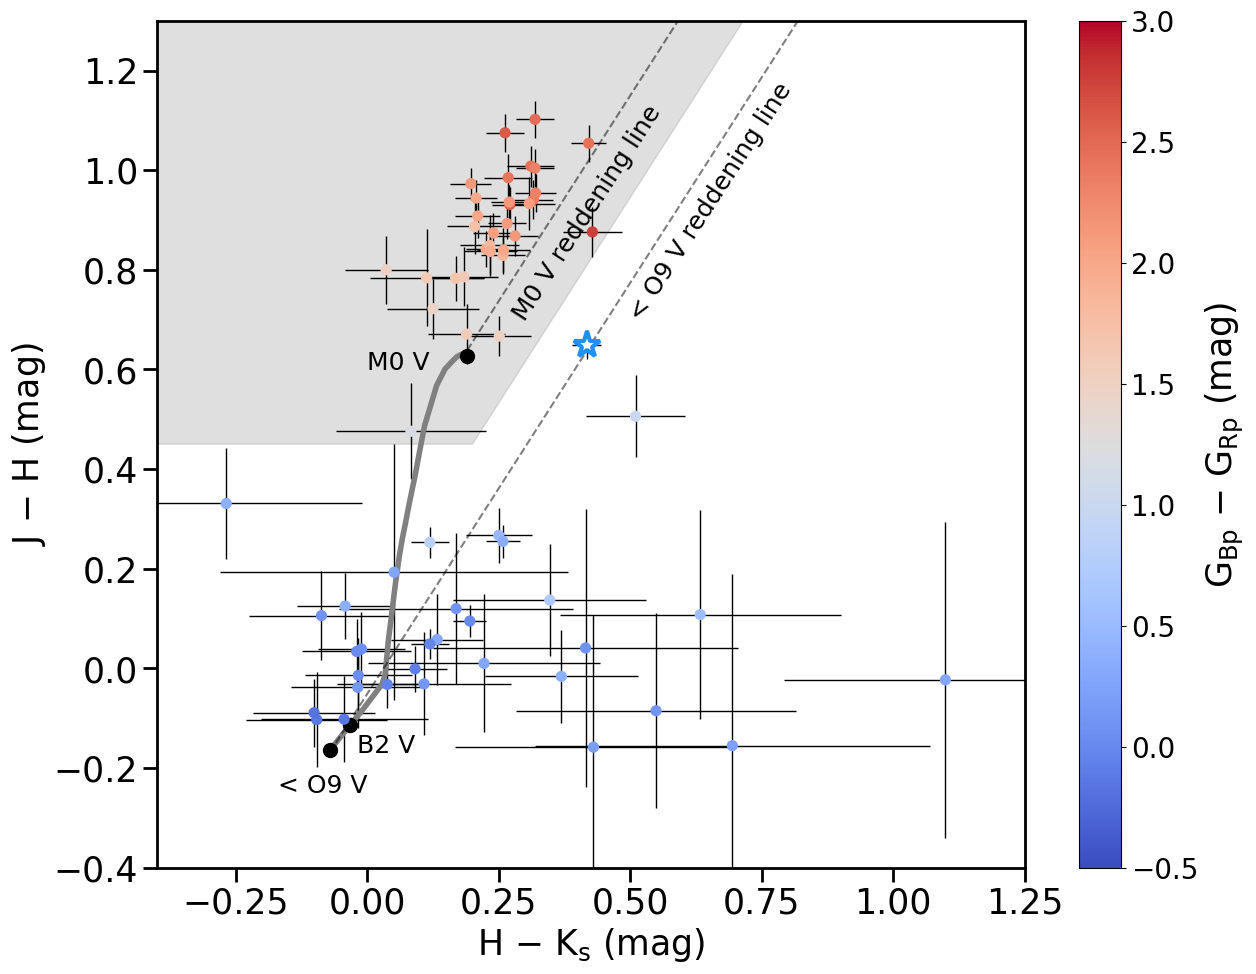

In [16]:
fig, ax = plt.subplots(1, figsize=(14, 11))

my_ax = ax.scatter(runaways_best.h_k[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], runaways_best.j_h[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], c=runaways_best.bp_rp[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))],
                  cmap='coolwarm', vmin=-0.5, vmax=3.0, marker='o', s=50., zorder=0)
ax.errorbar(runaways_best.h_k[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], runaways_best.j_h[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))],
           xerr=runaways_best.h_k_error[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], yerr=runaways_best.j_h_error[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))],
           fmt='ko', ecolor='k', elinewidth=1, ms=0., zorder=-1)

# VFTS 682
ax.plot(runaways_best[runaways_best.source_id == 4657685637907503744].h_k, runaways_best[runaways_best.source_id == 4657685637907503744].j_h,
        'b*', mfc='w', mec='dodgerblue', mew=3., ms=20., label='VFTS 682')

cb = fig.colorbar(my_ax, ticks=np.arange(-0.5, 3.5, 0.5))
# cb.ax.set_yticklabels(['WR', 'WNh', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'B or later', 'Unknown'])  # vertically oriented colorbar
cb.set_label(r'G$_{\rm{Bp}}$ $-$ G$_{\rm{Rp}}$ (mag)', fontsize=25)
cb.ax.tick_params(labelsize=20)
# cb.ax.invert_yaxis()

# ax.errorbar(runaways_best.h_k[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], runaways_best.j_h[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], xerr=runaways_best.h_k_error[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))], yerr=runaways_best.j_h_error[(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom))],
#             fmt='bo', ms=0., ecolor='k', elinewidth=1)

mamajek_h_k = np.array([0.190, 0.180, 0.171, 0.164, 0.148, 0.132, 0.109, 0.098, 0.091, 0.082, 0.076, 0.073, 0.067, 0.061, 0.054, 0.051, 0.045, 0.040, 0.038, 0.034, 0.028,
                        -0.013, -0.026, -0.032, -0.067, -0.071])
mamajek_j_h = np.array([0.627, 0.631, 0.626, 0.619, 0.601, 0.568, 0.487, 0.427, 0.387, 0.342, 0.310, 0.293, 0.262, 0.225, 0.173, 0.148, 0.096, 0.055, 0.031, -0.012, -0.032,
                        -0.089, -0.105, -0.113, -0.159, -0.164])
ax.plot(mamajek_h_k, mamajek_j_h, c='gray', ls='-', lw=4, zorder=-1)

# O9 V star
ax.plot(-0.071, -0.164, 'ko', ms=10., zorder=-0.5)
ax.text(-0.17, -0.25, '< O9 V', fontsize=18)

# B2 V star
ax.plot(-0.032, -0.113, 'ko', ms=10., zorder=-0.5)
ax.text(-0.02, -0.17, 'B2 V', fontsize=18)

# M0 V star 0.627  0.190
ax.plot(0.190, 0.627, 'ko', ms=10., zorder=-0.5)
ax.text(0.0, 0.6, 'M0 V', fontsize=18)
 
# ax.axvline(0.9, color='r', ls='--')
# ax.plot(0.415, 0.65, 'rs')

# make red shaded area
x_plot = np.arange(-0.5, 1.5, 0.01)
x_cutoff = 0.20
y_cutoff = 0.45
y_plot = 1.65*x_plot + -(1.65*x_cutoff - y_cutoff)
y_plot[:int(x_cutoff*100+51)] = y_cutoff
ax.fill_between(x_plot, y_plot, np.zeros(len(y_plot)) + 2.0, color='gray', alpha=0.25, zorder=-2)


ax.plot(np.linspace(-0.071, 1.5, 100), 1.65*np.linspace(-0.071, 1.5, 100) - 0.05111, 'k--', alpha=0.5, zorder=-1)
ax.plot(np.linspace(0.190, 1.5, 100), 1.65*np.linspace(0.190, 1.5, 100) + 0.3249, 'k--', alpha=0.5, zorder=-1)
ax.text(0.49, 0.7, '< O9 V reddening line', c='k', rotation=57., fontsize=18)


ax.text(0.27, 0.7, 'M0 V reddening line', c='k', rotation=57., fontsize=18)

ax.set_xlim(-0.4, 1.25)
ax.set_ylim(-0.4, 1.3)
ax.set_xlabel(r'H $-$ K$_{\rm{s}}$ (mag)', fontsize=25)
ax.set_ylabel('J $-$ H (mag)', fontsize=25)
ax.tick_params(labelsize=25)
# plt.gca().invert_yaxis()

for my_ax in [ax]:
    for axis in ['top','bottom','left','right']:
        my_ax.spines[axis].set_linewidth(2)

        my_ax.tick_params(axis='y', which='major', direction='out', length=10, width=2)
        my_ax.tick_params(axis='y', which='minor', direction='out', length=5, width=2)
        my_ax.tick_params(axis='x', which='major', direction='out', length=10, width=2)
        my_ax.tick_params(axis='x', which='minor', direction='out', length=5, width=2)

plt.savefig('figures/figures_paper/runaways_jh_hk.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/figures_paper/extended_data/runaways_jh_hk.jpeg', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
print(len(runaways_best))
outliers = runaways_best.copy()
outliers = outliers[(outliers.j_h > 0.4)&(outliers.j_h > 1.65*outliers.h_k + -(1.65*x_cutoff - y_cutoff))&(~np.isnan(outliers.h_msigcom))&(~np.isnan(outliers.ks_msigcom))&(~np.isnan(outliers.j_msigcom))]
runaways_best = runaways_best[~((runaways_best.j_h > 0.4)&(runaways_best.j_h > 1.65*runaways_best.h_k + -(1.65*x_cutoff - y_cutoff))&(~np.isnan(runaways_best.h_msigcom))&(~np.isnan(runaways_best.ks_msigcom))&(~np.isnan(runaways_best.j_msigcom)))]
print(len(runaways_best))
print(len(outliers))



102
70
32


C:\Users\bukow\AppData\Local\Temp\ipykernel_64868\3588772164.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs" (-> color='r'). The keyword argument will take precedence.
  ax.plot(outliers.bp_rp[(np.isnan(outliers.h_msigcom))|(np.isnan(outliers.ks_msigcom))|(np.isnan(outliers.j_msigcom))], outliers.phot_g_mean_mag[(np.isnan(outliers.h_msigcom))|(np.isnan(outliers.ks_msigcom))|(np.isnan(outliers.j_msigcom))],
C:\Users\bukow\AppData\Local\Temp\ipykernel_64868\3588772164.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs" (-> color='r'). The keyword argument will take precedence.
  ax.plot(outliers.bp_rp, outliers.phot_g_mean_mag,


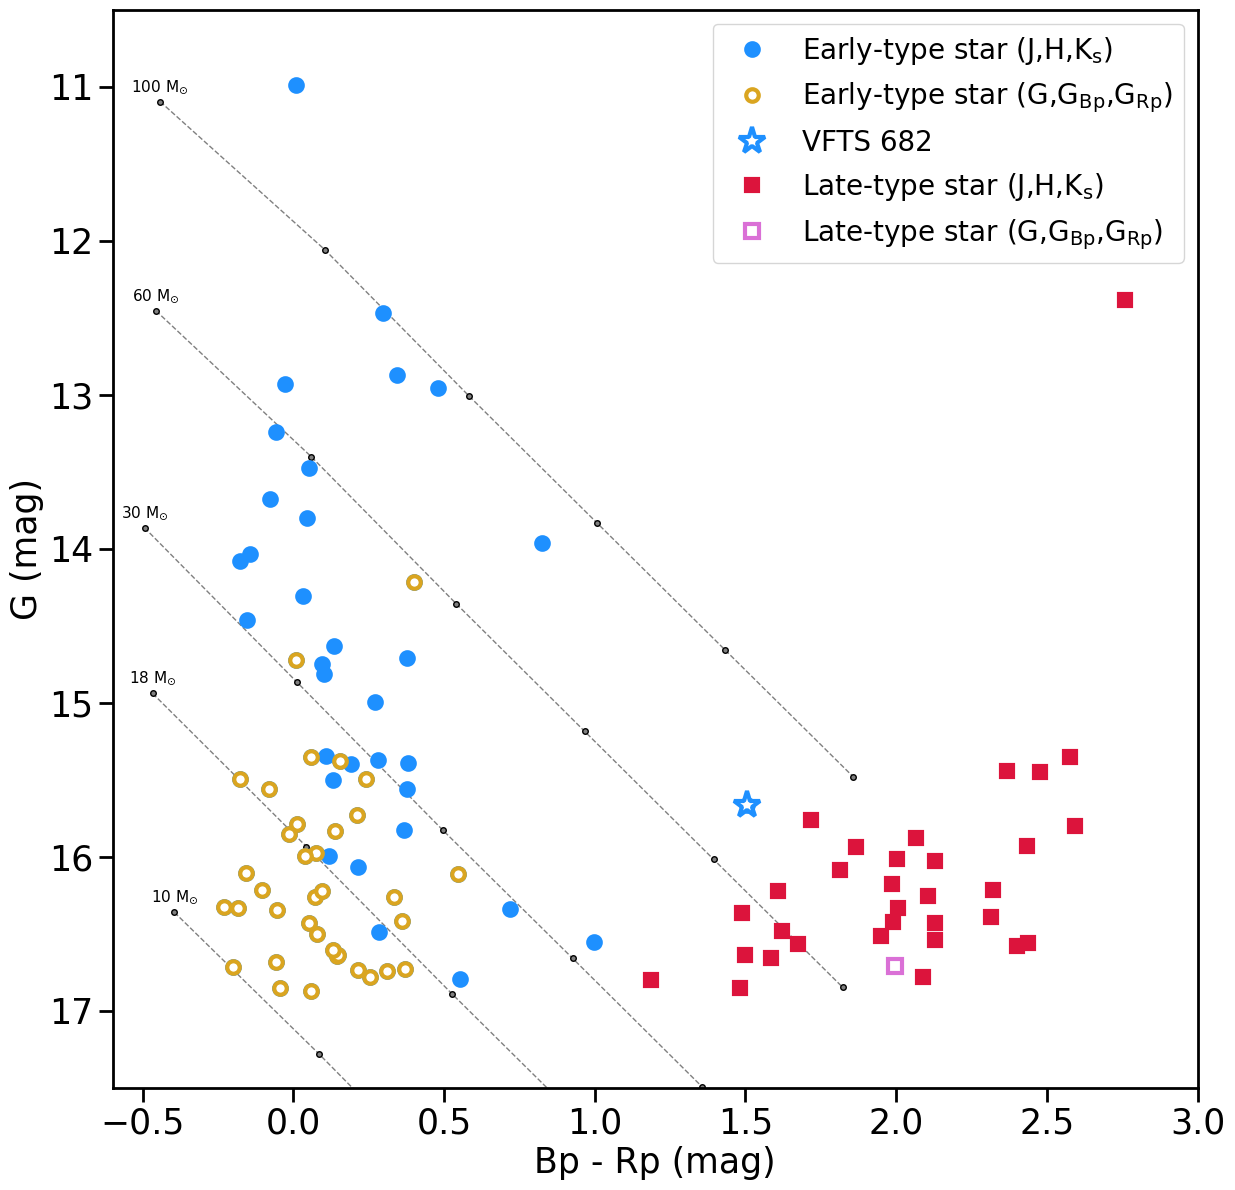

In [18]:
fig, ax = plt.subplots(1, figsize=(14, 14))

# outliers / red giants
ax.plot(outliers.bp_rp[(np.isnan(outliers.h_msigcom))|(np.isnan(outliers.ks_msigcom))|(np.isnan(outliers.j_msigcom))], outliers.phot_g_mean_mag[(np.isnan(outliers.h_msigcom))|(np.isnan(outliers.ks_msigcom))|(np.isnan(outliers.j_msigcom))],
        'rs', color='crimson', mfc='w', mec='r', mew=3., ms=8., zorder=1)

# actual runaways
ax.plot(runaways_best.bp_rp, runaways_best.phot_g_mean_mag,
        'bo', mfc='dodgerblue', mec='dodgerblue', mew=3., ms=9., label=r'Early-type star (J,H,K$_{\rm{s}}$)', zorder=1)
ax.plot(runaways_best.bp_rp[((np.isnan(runaways_best.h_msigcom))|(np.isnan(runaways_best.ks_msigcom))|(np.isnan(runaways_best.j_msigcom)))&(runaways_best.bp_rp < 0.9)], runaways_best.phot_g_mean_mag[(((np.isnan(runaways_best.h_msigcom))|(np.isnan(runaways_best.ks_msigcom))|(np.isnan(runaways_best.j_msigcom)))&(runaways_best.bp_rp < 0.9))],
        'bo', mfc='w', mec='goldenrod', mew=3., ms=9., label=r'Early-type star (G,G$_{\rm{Bp}}$,G$_{\rm{Rp}}$)', zorder=1)
ax.plot(runaways_best[runaways_best.source_id == 4657685637907503744].bp_rp, runaways_best[runaways_best.source_id == 4657685637907503744].phot_g_mean_mag,
        'b*', mfc='w', mec='dodgerblue', mew=3., ms=20., label='VFTS 682', zorder=1)

# late-type interlopers
ax.plot(outliers.bp_rp, outliers.phot_g_mean_mag,
        'rs', color='crimson', mfc='crimson', mec='crimson', mew=3., ms=8., label=r'Late-type star (J,H,K$_{\rm{s}}$)', zorder=1)
ax.plot(runaways_best.bp_rp[((np.isnan(runaways_best.h_msigcom))|(np.isnan(runaways_best.ks_msigcom))|(np.isnan(runaways_best.j_msigcom)))&(runaways_best.bp_rp > 0.9)], runaways_best.phot_g_mean_mag[(((np.isnan(runaways_best.h_msigcom))|(np.isnan(runaways_best.ks_msigcom))|(np.isnan(runaways_best.j_msigcom)))&(runaways_best.bp_rp > 0.9))],
        'bs', mfc='w', mec='orchid', mew=3., ms=10., label=r'Late-type star (G,G$_{\rm{Bp}}$,G$_{\rm{Rp}}$)', zorder=1)

av_array = np.arange(0.0, 6.0, 1.0)
r136_age = 6.25527

m100_xarray = []
m100_yarray = []

m60_xarray = []
m60_yarray = []

m30_xarray = []
m30_yarray = []

m18_xarray = []
m18_yarray = []

m10_xarray = []
m10_yarray = []

for cur_av in av_array:
    # PLOT ISOCHRONE
    isochrone = np.genfromtxt(input_files_dir + 'parsec_isochrones/Isochrones_age_Av' + str(cur_av)[0] + '_' + str(cur_av)[2] + '.txt', dtype=float, comments='#')
    # all different ages in the isochrones
    all_ages = np.unique(isochrone[:,2])
    cur_isochrone = isochrone[isochrone[:,2] == r136_age]

    x_m100 = cur_isochrone[:,-2][cur_isochrone[:,3] == 100.0000000000] - cur_isochrone[:,-1][cur_isochrone[:,3] == 100.0000000000]
    y_m100 = cur_isochrone[:,-3][cur_isochrone[:,3] == 100.0000000000] + 18.49
    m100_xarray.append(x_m100)
    m100_yarray.append(y_m100)
    
    x_m60 = cur_isochrone[:,-2][cur_isochrone[:,3] == 60.0000000000] - cur_isochrone[:,-1][cur_isochrone[:,3] == 60.0000000000]
    y_m60 = cur_isochrone[:,-3][cur_isochrone[:,3] == 60.0000000000] + 18.49
    m60_xarray.append(x_m60)
    m60_yarray.append(y_m60)

    x_m30 = cur_isochrone[:,-2][cur_isochrone[:,3] == 30.0000000000] - cur_isochrone[:,-1][cur_isochrone[:,3] == 30.0000000000]
    y_m30 = cur_isochrone[:,-3][cur_isochrone[:,3] == 30.0000000000] + 18.49
    m30_xarray.append(x_m30)
    m30_yarray.append(y_m30)

    x_m18 = cur_isochrone[:,-2][cur_isochrone[:,3] == 18.0000000000] - cur_isochrone[:,-1][cur_isochrone[:,3] == 18.0000000000]
    y_m18 = cur_isochrone[:,-3][cur_isochrone[:,3] == 18.0000000000] + 18.49
    m18_xarray.append(x_m18)
    m18_yarray.append(y_m18)

    x_m10 = cur_isochrone[:,-2][cur_isochrone[:,3] == 10.0000000000] - cur_isochrone[:,-1][cur_isochrone[:,3] == 10.0000000000]
    y_m10 = cur_isochrone[:,-3][cur_isochrone[:,3] == 10.0000000000] + 18.49
    m10_xarray.append(x_m10)
    m10_yarray.append(y_m10)

ax.plot(m100_xarray, m100_yarray, ls='--', marker='', c='gray', lw=1, ms=0.0, zorder=-1)
ax.plot(m60_xarray, m60_yarray, ls='--', marker='', c='gray', lw=1, ms=0.0, zorder=-1)
ax.plot(m30_xarray, m30_yarray, ls='--', marker='', c='gray', lw=1, ms=0.0, zorder=-1)
ax.plot(m18_xarray, m18_yarray, ls='--', marker='', c='gray', lw=1, ms=0.0, zorder=-1)
ax.plot(m10_xarray, m10_yarray, ls='--', marker='', c='gray', lw=1, ms=0.0, zorder=-1)

ax.plot(m100_xarray, m100_yarray, ls='', marker='o', ms=4.0, mew=1.0, mec='k', mfc='gray', zorder=-1)
ax.plot(m60_xarray, m60_yarray, ls='', marker='o', ms=4.0, mew=1.0, mec='k', mfc='gray', zorder=-1)
ax.plot(m30_xarray, m30_yarray, ls='', marker='o', ms=4.0, mew=1.0, mec='k', mfc='gray', zorder=-1)
ax.plot(m18_xarray, m18_yarray, ls='', marker='o', ms=4.0, mew=1.0, mec='k', mfc='gray', zorder=-1)
ax.plot(m10_xarray, m10_yarray, ls='', marker='o', ms=4.0, mew=1.0, mec='k', mfc='gray', zorder=-1)

ax.text(m100_xarray[0], m100_yarray[0] - 0.1, r'100 M$_{\odot}$', ha='center', va='center', fontsize=11, zorder=-1)
ax.text(m60_xarray[0], m60_yarray[0] - 0.1, r'60 M$_{\odot}$', ha='center', va='center', fontsize=11, zorder=-1)
ax.text(m30_xarray[0], m30_yarray[0] - 0.1, r'30 M$_{\odot}$', ha='center', va='center', fontsize=11, zorder=-1)
ax.text(m18_xarray[0], m18_yarray[0] - 0.1, r'18 M$_{\odot}$', ha='center', va='center', fontsize=11, zorder=-1)
ax.text(m10_xarray[0], m10_yarray[0] - 0.1, r'10 M$_{\odot}$', ha='center', va='center', fontsize=11, zorder=-1)

ax.set_xlim(-0.6, 3.0)
ax.set_ylim(10.5, 17.5)
ax.set_xlabel('Bp - Rp (mag)', fontsize=25)
ax.set_ylabel('G (mag)', fontsize=25)
ax.tick_params(labelsize=25)
plt.gca().invert_yaxis()

ax.legend(fontsize=20)

for my_ax in [ax]:
    for axis in ['top','bottom','left','right']:
        my_ax.spines[axis].set_linewidth(2)

        my_ax.tick_params(axis='y', which='major', direction='out', length=10, width=2)
        my_ax.tick_params(axis='y', which='minor', direction='out', length=5, width=2)
        my_ax.tick_params(axis='x', which='major', direction='out', length=10, width=2)
        my_ax.tick_params(axis='x', which='minor', direction='out', length=5, width=2)

plt.savefig('figures/figures_paper/runaways_g_bprp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/figures_paper/runaways_g_bprp.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/figures_paper/extended_data/runaways_g_bprp.jpeg', dpi=300, bbox_inches='tight')

plt.show()


In [19]:
print(len(outliers))
print(len(runaways_best))
runaways_best = runaways_best[(~(((np.isnan(runaways_best.h_msigcom))|(np.isnan(runaways_best.ks_msigcom))|(np.isnan(runaways_best.j_msigcom)))&(runaways_best.bp_rp > 1.0)))&(runaways_best.source_id != 4657735184625817856)]
print(len(outliers))
print(len(runaways_best))
outliers.to_csv(output_dir + 'runaways_outliers_mcmc.csv', index=False)


32
70
32
69


# Determine Transverse Velocity, Ejection Angle, and Kinematic Age with MCMC

In [20]:
def percentile00p15(x):
    return np.quantile(x,0.0015)
def percentile00p3(x):
    return np.quantile(x,0.003)
def percentile02p5(x):
    return np.quantile(x,0.025)
def percentile05(x):
    return np.quantile(x,0.05)
def percentile16(x):
    return np.quantile(x,0.15865)
def percentile32(x):
    return np.quantile(x,0.32)
def percentile50(x):
    return np.quantile(x,0.50)
def percentile68(x):
    return np.quantile(x,0.68)
def percentile84(x):
    return np.quantile(x,0.84135)
def percentile95(x):
    return np.quantile(x,0.95)
def percentile97p5(x):
    return np.quantile(x,0.975)
def percentile99p7(x):
    return np.quantile(x,0.997)
def percentile99p85(x):
    return np.quantile(x,0.9985)

def trace_sd(x):
    return pd.Series(np.std(x, 0), name='sd')

# obtain the kinematic age from the MCMC
def tkin_mcmc(l, l_cluster, b, b_cluster, distance_all, velocity_all, angle_all):
    tkin_all = []
    for i in np.arange(0, len(distance_all)):
        pml_rel = 1./distance_all[i]/4.74047 * velocity_all[i] * np.sin(angle_all[i])
        pmb_rel = 1./distance_all[i]/4.74047 * velocity_all[i] * np.cos(angle_all[i])
        time_array = np.flip(np.arange(-7.5e6, 0.001e6, 0.001e6))
        
        l_cur = (l - l_cluster) + time_array*(pml_rel)/(3.6e6 * np.cos(np.radians(b)))
        b_cur = (b - b_cluster) + time_array*(pmb_rel)/(3.6e6)
        
        r_impact = np.sqrt((l_cur)**2 + (b_cur)**2)
        r_impact_best = np.amin(r_impact)
        tkin_best = time_array[np.argmin(r_impact)]
    
        tkin_best = np.abs(tkin_best)/(1e6)

        if r_impact_best < 0.005:
            tkin_all.append(tkin_best)
    
    return tkin_all


# User input required

In [22]:
n_mcmc = 100000

##### uncomment one of these #####

##### start fresh
runaways = runaways_best.copy()
runaways['n_mcmc'] = np.zeros(len(runaways))

##### load in with some mcmc already done (e.g. if you ran the MCMC of only part of the sample)
# runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')

## With n_mcmc = 100000 this can take a long time
## Takes about ~ 6.5 minutes per star on my Macbook.
## With 69 runaways this can take 7-8 hours total.
## We give an example MCMC run for three runaways below, which takes about ~ 20 minutes

In [23]:
def runaway_mcmc(rw_sample, save=False):
    # run the MCMC for the rw_sample for which this is not done yet
    for index, row in rw_sample[rw_sample.n_mcmc != n_mcmc].iterrows():
    
        # astrometry and covariance matrix
        astr_i = np.array([row.parallax, row.pml - pml_cluster_best, row.pmb - pmb_cluster_best])
        print(astr_i)
        cov_i = np.zeros((3,3))
        cov_i[0,0] = row.parallax_error**2
        cov_i[1,1] = row.pml_error**2
        cov_i[2,2] = row.pmb_error**2
        cov_i[0,1] = row.parallax_pml_corr * row.parallax_error * row.pml_error
        cov_i[1,0] = cov_i[0,1]
        cov_i[0,2] = row.parallax_pmb_corr * row.parallax_error * row.pmb_error
        cov_i[2,0] = cov_i[0,2]
        cov_i[1,2] = row.pml_pmb_corr * row.pml_error * row.pmb_error
        cov_i[2,1] = cov_i[1,2]
    
        # set the angle of ejection
        if astr_i[1] == 0:
            if astr_i[2] > 0:
                ang0=0.
            else:
                if astr_i[2] < 0:
                    ang0=-np.pi
        else:
            ang0=np.arctan(astr_i[1]/astr_i[2])
            if astr_i[1] < 0 and astr_i[2] < 0:
                ang0=ang0+np.pi
            else:
                if astr_i[1] > 0 and astr_i[2] < 0:
                    ang0=ang0+np.pi/2
    
        # MCMC model
        with pm.Model() as myModel:
        
            # The priors
            distance = pm.Normal('distance', mu=49.59, sigma=0.011*49.59)
            velocity = pm.Uniform('velocity', lower=0.0, upper=250.0)
            angle    = pm.Uniform('angle', lower=ang0-np.pi, upper=ang0+np.pi)
            
            # Expected value of x given the distance, the tangential velocity, and the angle
            c2 = 4.74047
            mu = [1./distance, 1./distance/c2  * velocity * np.sin(angle), 1./distance/c2 *velocity * np.cos(angle)]
            
            # The likelihood
            
            x = pm.MvNormal('x', mu=mu, cov=cov_i, observed=astr_i)
            
            # Sample the posterios
            
            trace = pm.sample(n_mcmc)
    
        # get the posterior values
        res=pm.summary(trace, stat_funcs=[percentile00p15,percentile00p3,percentile02p5,
                                       percentile05,percentile16,percentile32,
                                       percentile50,
                                       percentile68,percentile84,percentile95,
                                       percentile97p5,percentile99p7,percentile99p85])
        
        maxAPosteriori = pm.find_MAP( model=myModel)
        
        names = ['distance', 'velocity', 'angle']
        unitFactors = [1, 1, 180./np.pi]
        units = ["kpc", "km/s", "deg"]
        posterior_values=[]
        for name, unitFactor, unit in zip(names, unitFactors, units):
            posterior_values.append(maxAPosteriori[name])
            print(name + ": ", unitFactor * maxAPosteriori[name], unit)
    
        # get the velocity and 1 sigma uncertainty
        rw_sample.loc[rw_sample.source_id == row.source_id, ['v_t']] = res.percentile50.iloc[1]
        rw_sample.loc[rw_sample.source_id == row.source_id, ['v_t_error_plus']] = res.percentile84.iloc[1] - res.percentile50.iloc[1]
        rw_sample.loc[rw_sample.source_id == row.source_id, ['v_t_error_min']] = res.percentile50.iloc[1] - res.percentile16.iloc[1]
    
        # determine the kinematic age from the posterior
        tracedf = az.convert_to_dataset(trace)
        tracedf = tracedf.as_numpy()
        distance_all = np.concatenate(tracedf.distance.data)
        vt_all = np.concatenate(tracedf.velocity.data)
        angle_all = np.concatenate(tracedf.angle.data)
        tkin_all = tkin_mcmc(row.l, l_cluster, row.b, b_cluster, distance_all, vt_all, angle_all)
    
        # get the velocity and 1 sigma uncertainty
        rw_sample.loc[rw_sample.source_id == row.source_id, ['t_kin']] = np.percentile(tkin_all, 50)
        rw_sample.loc[rw_sample.source_id == row.source_id, ['t_kin_error_plus']] = np.percentile(tkin_all, 84.135) - np.percentile(tkin_all, 50)
        rw_sample.loc[rw_sample.source_id == row.source_id, ['t_kin_error_min']] = np.percentile(tkin_all, 50) - np.percentile(tkin_all, 15.865)
    
        # get the velocity and 1 sigma uncertainty
        rw_sample.loc[rw_sample.source_id == row.source_id, ['angle_ejec']] = np.percentile(angle_all, 50)
        rw_sample.loc[rw_sample.source_id == row.source_id, ['angle_ejec_error_plus']] = np.percentile(angle_all, 84.135) - np.percentile(angle_all, 50)
        rw_sample.loc[rw_sample.source_id == row.source_id, ['angle_ejec_error_min']] = np.percentile(angle_all, 50) - np.percentile(angle_all, 15.865)
        rw_sample.loc[rw_sample.source_id == row.source_id, ['n_mcmc']] = n_mcmc
    
        print(row.source_id)
        print(res.percentile50.iloc[1], res.percentile84.iloc[1] - res.percentile50.iloc[1], res.percentile50.iloc[1] - res.percentile16.iloc[1])
        print(np.percentile(tkin_all, 50), np.percentile(tkin_all, 84.135) - np.percentile(tkin_all, 50), np.percentile(tkin_all, 50) - np.percentile(tkin_all, 15.865))
        print(np.percentile(angle_all, 50), np.percentile(angle_all, 84.135) - np.percentile(angle_all, 50), np.percentile(angle_all, 50) - np.percentile(angle_all, 15.865))
        print('\n')
    
        # plot the posteriors
        fact=[1.,200,180/np.pi]
        names_plot = ['distance (kpc)', 'velocity (km/s)', 'angle (rad)']
        fig = corner.corner(trace, labels=names_plot, quantiles=(0.15865,0.5, 0.84135),truths=posterior_values,show_titles=True)
        plt.show()
    
        # plot the kinematic age
        fig, ax = plt.subplots(1, figsize=(10,10))
        ax.hist(tkin_all, bins=30, color='b', ec='w', range=(np.percentile(tkin_all, 1),np.percentile(tkin_all, 99)))
        ax.axvline(np.percentile(tkin_all, 50), color='r', ls='-')
        ax.axvline(np.percentile(tkin_all, 84.135), color='r', ls='--')
        ax.axvline(np.percentile(tkin_all, 15.865), color='r', ls='--')
        ax.set_xlabel('Kinematic Age (Myr)', fontsize=15)
        ax.set_ylabel('N', fontsize=15)
        plt.show()
    
        # if the runaway does not satisfy the criteria, it is excluded from the sample
        # velocity should not be smaller than 27.6 km/s
        # velocity / velocity_error should not be smaller than 3
        # kinematic age should not be larger than 3 Myr
        if (res.percentile50.iloc[1] < 27.6) or (res.percentile50.iloc[1] / (res.percentile50.iloc[1] - res.percentile16.iloc[1]) < 3) or (np.percentile(tkin_all, 50) > 3.0):
            rw_sample = rw_sample[rw_sample.source_id != row.source_id]
    
        # write the runaways again to the same file so that progress in the MCMC is saved
        if save == True:
            rw_sample.to_csv(output_dir + 'runaways_mcmc.csv', index=False)

# User input required

[ 0.05154626 -0.03159974  0.13474821]


C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [distance, velocity, angle]


Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 727 seconds.



distance:  49.58648029556197 kpc
velocity:  30.063892012933565 km/s
angle:  -20.287126299040388 deg
4657685599216261376
28.304 10.101000000000003 10.392999999999997
0.757 0.3670000000000001 0.18600000000000005
-0.355564234170368 0.3717596285945632 0.3735249598999294




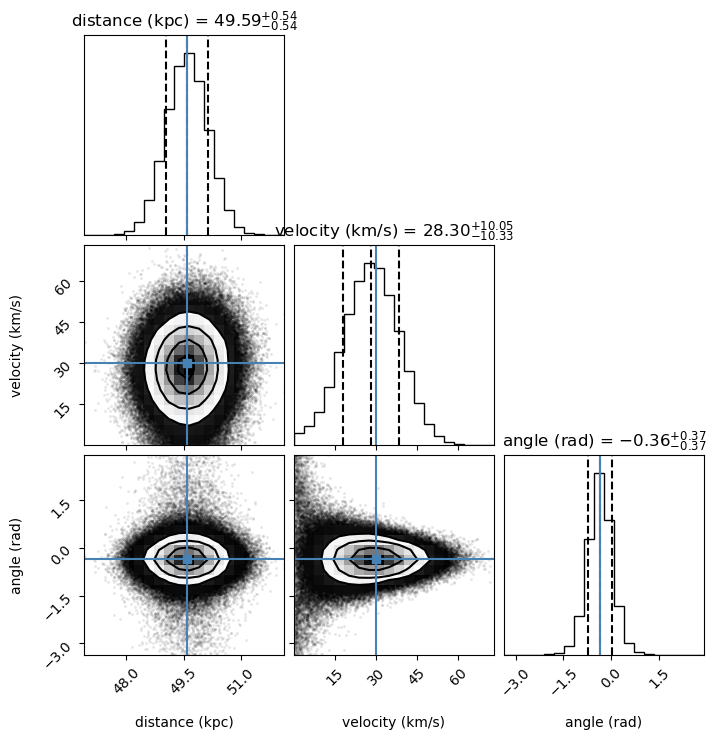

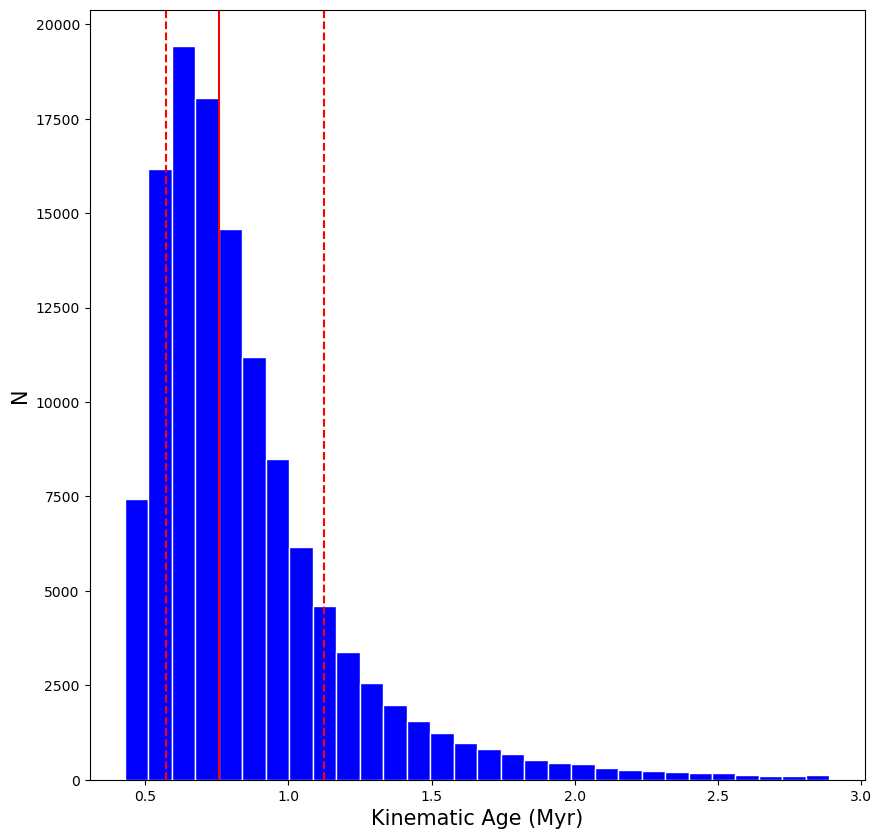

[ 0.03013586  0.09489799 -0.33491515]


C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [distance, velocity, angle]


Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 591 seconds.



distance:  49.5831427786529 kpc
velocity:  82.46876277018148 km/s
angle:  164.6264565082783 deg
4657690620070706432
82.355 4.197999999999993 4.195000000000007
1.442 0.07499999999999996 0.06799999999999984
2.873515472593352 0.04515377293426237 0.0452385029840956




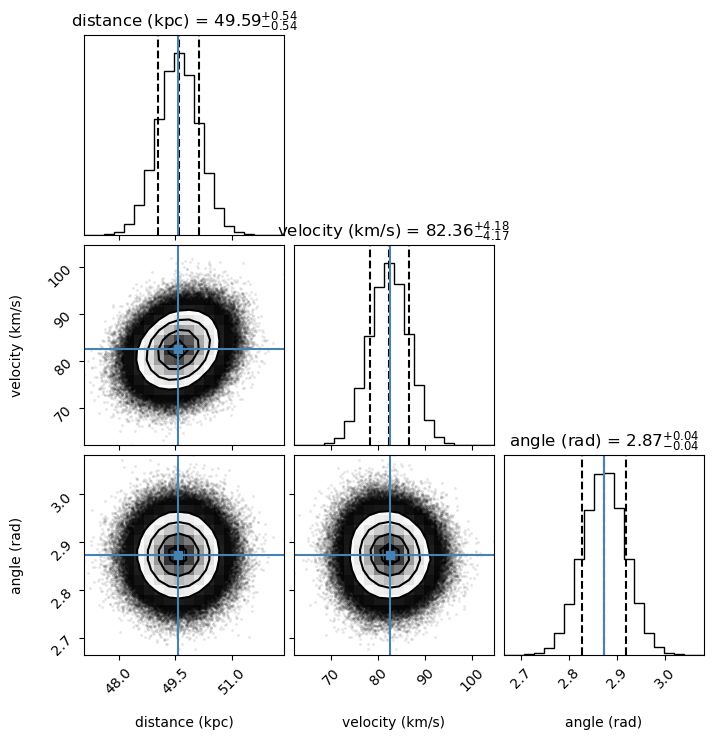

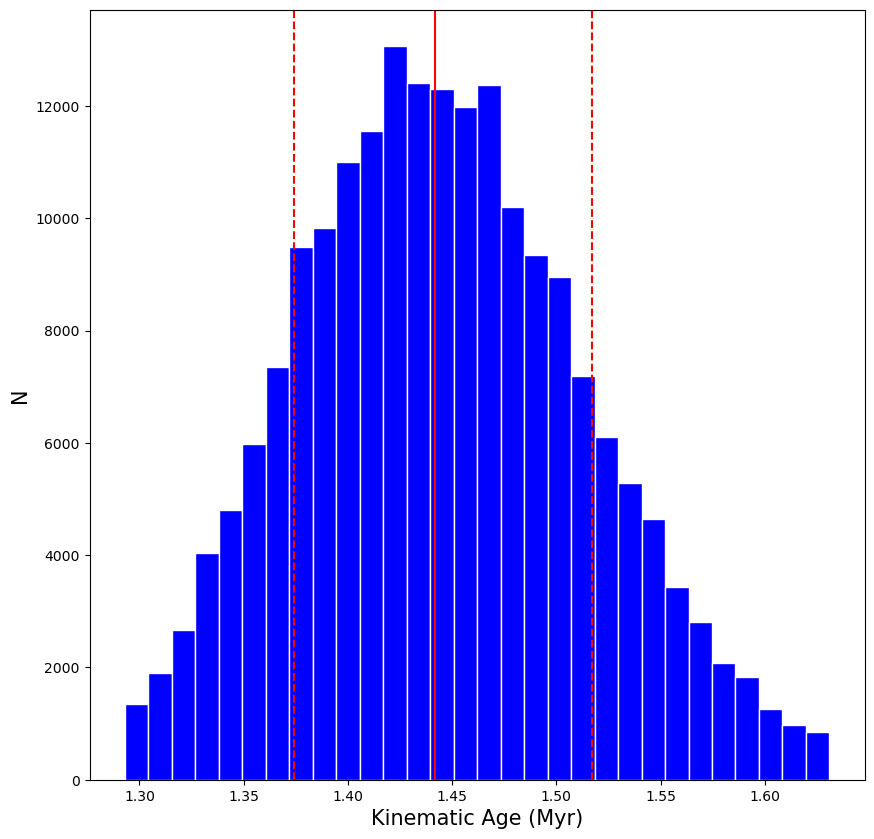

[ 0.04801764 -0.45433574 -0.1076209 ]


C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
C:\Users\bukow\anaconda3\envs\R136_waves\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1019: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [distance, velocity, angle]


Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 560 seconds.



distance:  49.573044338628755 kpc
velocity:  111.1254775287127 km/s
angle:  255.82127943695306 deg
4657783322622150784
111.007 4.870999999999995 4.864000000000004
1.719 0.07399999999999984 0.06900000000000017
4.46462838594601 0.03737699765846081 0.03814928371166193




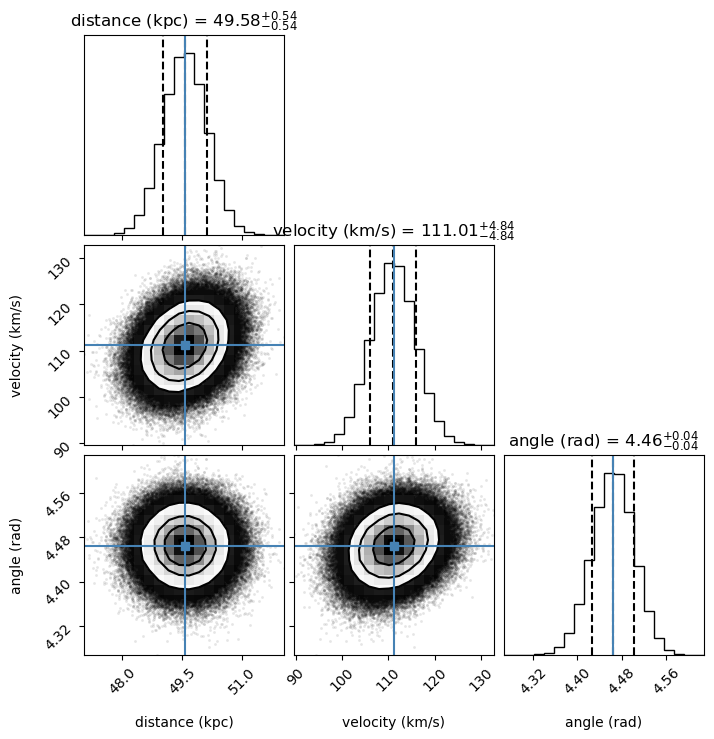

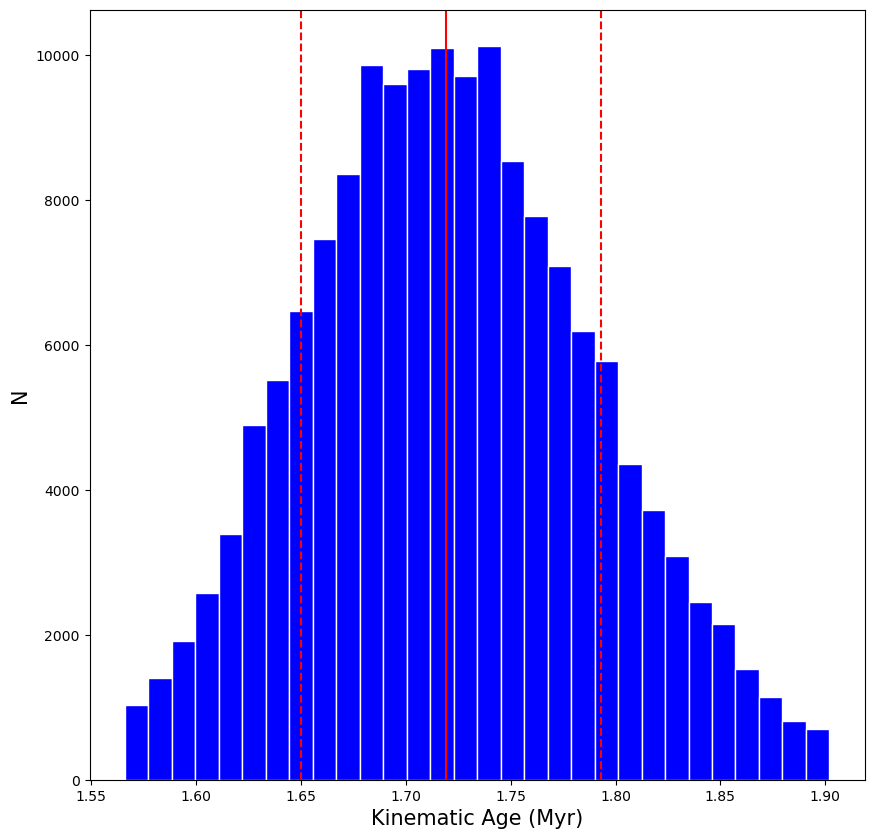

In [24]:
##### Uncomment one of the runs below #####

##### run the MCMC for the entire runaway sample
# runaway_mcmc(runaways, save=True)

##### run the MCMC for three runaways
##### one of these runaways is Gaia DR3 4657685599216261376 (VFTS 706) and does not have a significant velocity and is eventually excluded
##### one of these runaways is Gaia DR3 4657690620070706432 (VFTS 16) and satisfies all criteria and is a known runaway
##### one of these runaways is Gaia DR3 4657783322622150784 (SK-68 137) and satisfies all criteria and is new runaway here
runaway_mcmc(runaways[(runaways.source_id == 4657690620070706432)|(runaways.source_id == 4657783322622150784)|(runaways.source_id == 4657685599216261376)],
             save=False)



# Write to csv and check if all MCMC is done

In [30]:
runaways.to_csv(output_dir + 'runaways_mcmc.csv', index=False)

In [26]:
print(len(runaways))
print(len(runaways[runaways.n_mcmc != 100000]))


69
69


# Write to csv files

## Small diagnostics first

In [28]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')

print(runaways.shape)
print(runaways.columns.tolist())

print("\nColumns containing 'angle':")
print([c for c in runaways.columns if 'angle' in c.lower()])

print("\nColumns containing 'ejec':")
print([c for c in runaways.columns if 'ejec' in c.lower()])

print("\nColumns containing 'kin':")
print([c for c in runaways.columns if 'kin' in c.lower()])

(69, 237)
['solution_id', 'designation', 'random_index', 'ref_epoch', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr', 'ra_pmdec_corr', 'dec_parallax_corr', 'dec_pmra_corr', 'dec_pmdec_corr', 'parallax_pmra_corr', 'parallax_pmdec_corr', 'pmra_pmdec_corr', 'astrometric_n_obs_al', 'astrometric_n_obs_ac', 'astrometric_n_good_obs_al', 'astrometric_n_bad_obs_al', 'astrometric_gof_al', 'astrometric_chi2_al', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'astrometric_params_solved', 'astrometric_primary_flag', 'nu_eff_used_in_astrometry', 'pseudocolour', 'pseudocolour_error', 'ra_pseudocolour_corr', 'dec_pseudocolour_corr', 'parallax_pseudocolour_corr', 'pmra_pseudocolour_corr', 'pmdec_pseudocolour_corr', 'astrometric_matched_transits', 'visibility_periods_used', 'astrometric_sigma5d_max', 'matched_transits', 'new_matched_transits', 'ma

cleaning possible hidden whitespace:

In [29]:
runaways.columns = runaways.columns.str.strip()

## Actual writing

In [31]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
runaways = runaways.sort_values('t_kin')

# transform ejection angles and to transform to degrees
runaways.loc[:, 'angle_ejec'] = 180 + (runaways.angle_ejec * 180.0 / np.pi)
runaways.loc[:, 'angle_ejec_error_min'] = (runaways.angle_ejec_error_min * 180.0 / np.pi)
runaways.loc[:, 'angle_ejec_error_plus'] = (runaways.angle_ejec_error_plus * 180.0 / np.pi)
runaways.loc[runaways.angle_ejec > 360, 'angle_ejec'] = runaways.angle_ejec - 360

runaways.to_csv(output_dir + 'runaways_mcmc.csv', index=False)

AttributeError: 'DataFrame' object has no attribute 'angle_ejec'

safer version:

In [32]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
runaways.columns = runaways.columns.str.strip()

runaways = runaways.sort_values('t_kin')

if 'angle_ejec' in runaways.columns:
    # Only convert if the angle still appears to be in radians
    if runaways['angle_ejec'].abs().max() < 2 * np.pi + 0.1:
        runaways.loc[:, 'angle_ejec'] = 180 + (runaways['angle_ejec'] * 180.0 / np.pi)
        runaways.loc[:, 'angle_ejec_error_min'] = runaways['angle_ejec_error_min'] * 180.0 / np.pi
        runaways.loc[:, 'angle_ejec_error_plus'] = runaways['angle_ejec_error_plus'] * 180.0 / np.pi
        runaways.loc[runaways['angle_ejec'] > 360, 'angle_ejec'] = runaways['angle_ejec'] - 360

    runaways.to_csv(output_dir + 'runaways_mcmc.csv', index=False)
else:
    print("No column called 'angle_ejec'. Existing angle/ejection columns are:")
    print([c for c in runaways.columns if ('angle' in c.lower()) or ('ejec' in c.lower())])

No column called 'angle_ejec'. Existing angle/ejection columns are:
['l_b_angle', 'pml_pmb_angle', 'angle_sky']


cell upgrade:

In [33]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
runaways.columns = runaways.columns.str.strip()
runaways = runaways.sort_values('t_kin')

# The notebook expects 'angle_ejec', but this version of the table uses 'angle_sky'
if 'angle_ejec' not in runaways.columns and 'angle_sky' in runaways.columns:
    runaways['angle_ejec'] = runaways['angle_sky']

# Convert ejection angle from radians to degrees, only if it is still in radians
if runaways['angle_ejec'].abs().max() < 2*np.pi + 0.1:
    runaways['angle_ejec'] = 180 + runaways['angle_ejec'] * 180.0 / np.pi
    runaways.loc[runaways['angle_ejec'] > 360, 'angle_ejec'] -= 360

runaways.to_csv(output_dir + 'runaways_mcmc.csv', index=False)

In [35]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
runaways.columns = runaways.columns.str.strip()

print(runaways.shape)

print("\nColumns containing velocity/v/v_t:")
print([c for c in runaways.columns if ('vel' in c.lower()) or (c.lower() in ['v', 'v_t', 'vt']) or ('v_t' in c.lower())])

print("\nColumns containing angle:")
print([c for c in runaways.columns if 'angle' in c.lower()])

print("\nColumns containing kin:")
print([c for c in runaways.columns if 'kin' in c.lower()])

print("\nAll columns:")
print(runaways.columns.tolist())

(69, 238)

Columns containing velocity/v/v_t:
['radial_velocity', 'radial_velocity_error', 'rv_time_duration', 'rv_template_teff', 'rv_template_logg', 'rv_template_fe_h', 'v_t', 'v_t_error']

Columns containing angle:
['l_b_angle', 'pml_pmb_angle', 'angle_sky', 'angle_ejec']

Columns containing kin:
['t_kin']

All columns:
['solution_id', 'designation', 'random_index', 'ref_epoch', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr', 'ra_pmdec_corr', 'dec_parallax_corr', 'dec_pmra_corr', 'dec_pmdec_corr', 'parallax_pmra_corr', 'parallax_pmdec_corr', 'pmra_pmdec_corr', 'astrometric_n_obs_al', 'astrometric_n_obs_ac', 'astrometric_n_good_obs_al', 'astrometric_n_bad_obs_al', 'astrometric_gof_al', 'astrometric_chi2_al', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'astrometric_params_solved', 'astrometric_primary_flag', 'nu_eff_used_in_a

In [34]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
print(runaways.shape)
print(runaways[['t_kin', 'velocity', 'angle_sky', 'angle_ejec']].head())
print(runaways[['t_kin', 'velocity', 'angle_ejec']].describe())

(69, 238)


KeyError: "['velocity'] not in index"

even safer cell:

In [36]:
cols_to_show = []

for c in ['t_kin', 't_kin_error_min', 't_kin_error_plus']:
    if c in runaways.columns:
        cols_to_show.append(c)

for c in ['velocity', 'v_t', 'vT', 'vel', 'velocity_median']:
    if c in runaways.columns:
        cols_to_show.append(c)

for c in ['angle_sky', 'angle_ejec', 'l_b_angle', 'pml_pmb_angle']:
    if c in runaways.columns:
        cols_to_show.append(c)

print("Showing columns:", cols_to_show)
display(runaways[cols_to_show].head())
display(runaways[cols_to_show].describe())

Showing columns: ['t_kin', 'v_t', 'angle_sky', 'angle_ejec', 'l_b_angle', 'pml_pmb_angle']


,t_kin,v_t,angle_sky,angle_ejec,l_b_angle,pml_pmb_angle
0,0.05,49.9,6.8,6.8,77.390212,70.560028
1,0.06,83.5,3.9,3.9,142.474326,146.405642
2,0.11,71.3,9.9,9.9,-178.032221,172.042542
3,0.13,40.0,8.3,8.3,-147.988152,-139.728628
4,0.17,30.5,3.0,3.0,-2.107814,-5.108615


,t_kin,v_t,angle_sky,angle_ejec,l_b_angle,pml_pmb_angle
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,1.473768,69.215942,9.320290,9.320290,-25.720145,-0.491037
std,0.863519,38.492526,7.192328,7.192328,121.978827,125.384555
min,0.050000,25.100000,0.000000,0.000000,-178.672744,-179.258735
25%,0.750000,40.700000,2.800000,2.800000,-140.899588,-127.005090
50%,1.650000,50.800000,8.300000,8.300000,-36.663504,-5.108615
75%,2.040000,90.700000,14.300000,14.300000,88.024902,121.750045
max,2.990000,189.400000,29.100000,29.100000,173.876917,179.870774


checking if the angle_ejec column actually exists:

In [37]:
print('angle_ejec' in runaways.columns)
print([c for c in runaways.columns if 'angle' in c.lower()])

True
['l_b_angle', 'pml_pmb_angle', 'angle_sky', 'angle_ejec']


relevant columns:

t_kin        kinematic age

v_t          transverse velocity

angle_sky    original sky-angle column

angle_ejec   added/converted ejection angle column

sanity check:

In [38]:
runaways = ps.read_csv(output_dir + 'runaways_mcmc.csv')
runaways.columns = runaways.columns.str.strip()

print(runaways[['t_kin', 'v_t', 'angle_sky', 'angle_ejec']].head())
print(runaways[['t_kin', 'v_t', 'angle_ejec']].describe())

print("angle_ejec min/max:", runaways['angle_ejec'].min(), runaways['angle_ejec'].max())

   t_kin   v_t  angle_sky  angle_ejec
0   0.05  49.9        6.8         6.8
1   0.06  83.5        3.9         3.9
2   0.11  71.3        9.9         9.9
3   0.13  40.0        8.3         8.3
4   0.17  30.5        3.0         3.0
           t_kin         v_t  angle_ejec
count  69.000000   69.000000   69.000000
mean    1.473768   69.215942    9.320290
std     0.863519   38.492526    7.192328
min     0.050000   25.100000    0.000000
25%     0.750000   40.700000    2.800000
50%     1.650000   50.800000    8.300000
75%     2.040000   90.700000   14.300000
max     2.990000  189.400000   29.100000
angle_ejec min/max: 0.0 29.1


###  Note that the runaway with source_id 4657685534828237056 has $v_{\rm{T}}$ / $\sigma_{v_{\rm{T}}}$ ~ 3.00. And depending on your run and n_mcmc it could just barely be or not be included in the final runaway sample

# From this, all figures in the paper can be produced